# Devoir 3 - Validation

##### A) Sachant que la LBM converge supposément à l’ordre 2 en espace (mais aussi en temps, mais ce n’est pas pertinent vu que l’on se préoccupe uniquement de l’état stationnaire), évaluer l’incertitude numérique $u_{\text{num}}$ au moyen d’une méthode appropriée vue en vérification de solution.
##### Ici aussi, rapporter clairement ce que vous avez fait pour estimer cette incertitude (c.-à-d. donner la liste des paramètres, l’étendue de l’analyse effectuée et tous les graphiques pertinents).
##### Pour faire une analyse de convergence appropriée, il vous faudra fixer la géométrie du milieu fibreux en gardant seulement, pour cette étape, le « seed » du générateur aléatoire constant (choisir n’importe quel entier) et garder $N_x \times \Delta x$ constant, de sorte que la position des fibres et la dimension du domaine restent elles aussi constantes.

**Réponse :** 

On doit commencer par déterminer $u_{num}$, l'incertitude numérique sur la perméabilité $k$ (due au maillage). SRQ = perméabilité $k$

Il faut absolument garder la seed constante (on choisit seed=101 comme dans le code) et le produit $N_x*\delta{x}$ constant (on garde 2*10e-4 comme dans le code).

Il faut effectuer la simulation pour 3 types de maillages :

- Grossier ($N_x=50$ et $\delta{x}=4*10^{-6}$)

- Moyen ($N_x=100$ et $\delta{x}=2*10^{-6}$)

- Fin ($N_x=200$ et $\delta{x}=10^{-6}$)



On obtient :
- $k_{grossier}=33.1245 \ m^2$
- $k_{moyen}=28.4648 \ m^2$
- $k_{fin}=27.7581 \ m^2$

On calcule l'ordre de convergence observé :
$$\hat{p}=\frac{ln(\frac{k_{grossier}-k_{moyen}}{k_{moyen}-k_{fin}})}{ln(2)}$$

Ainsi que le rapport :

$$|\frac{\hat{p}-p_f}{p_f}|$$

avec $p_f=2$ (ordre de convergence théorique donné par l'énoncé). 

Finalement, l'erreur numérique estimée vaut :
$$ u_{num} = 0.7067 \ m^2$$

soit $$ k = 27.7581 \pm 0.7067 \ m^2 $$

L’étude de convergence montre que la perméabilité diminue avec le raffinement du maillage 
car $k_{fin} < k_{moyen} < k_{grosser}$, ce qui indique une convergence monotone de la solution numérique.

L’ordre de convergence observé est $\hat{p} ≈ 2.72$ qui est supérieur à l’ordre théorique attendu (p_f=2). 
Cela suggère que la solution est proche du régime asymptotique.

L’incertitude numérique estimée est faible par rapport à la valeur de la perméabilité (≈ 2–3\%), ce qui indique une bonne précision de la solution.

d_equivalent     = 13.4049 µm
number_of_fibres = 30
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente normale.
Convergence après 416 pas de temps.

poro_eff         = 0.902000
Re               = 6.306939e-03
k_in_micron2     = 33.124543 µm²
d_equivalent     = 14.1506 µm
number_of_fibres = 27
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente normale.
  pas    500 | FlowRate = 2.421058e+02
Convergence après 773 pas de temps.

poro_eff         = 0.895200
Re               = 6.503555e-03
k_in_micron2     = 34.865160 µm²
d_equivalent     = 12.9992 µm
number_of_fibres = 32
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente normale.
  pas    500 | FlowRate = 2.541795e+02
Convergence après 756 pas de temps.

poro_eff         = 0.903200
Re               = 6.851448e-03
k_in_micron2     = 36.604348 µm²
d_equivalent     = 13.9045 µm
number_of_fibres = 27
Démarr

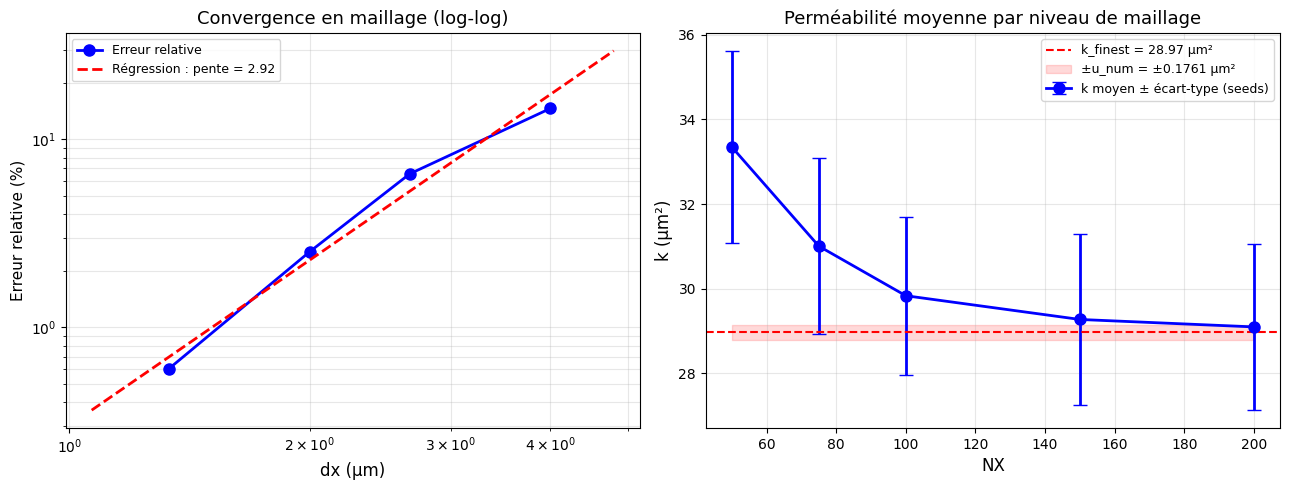

d_equivalent     = 13.4049 µm
number_of_fibres = 30
d_equivalent     = 13.4049 µm
number_of_fibres = 30
d_equivalent     = 13.4049 µm
number_of_fibres = 30


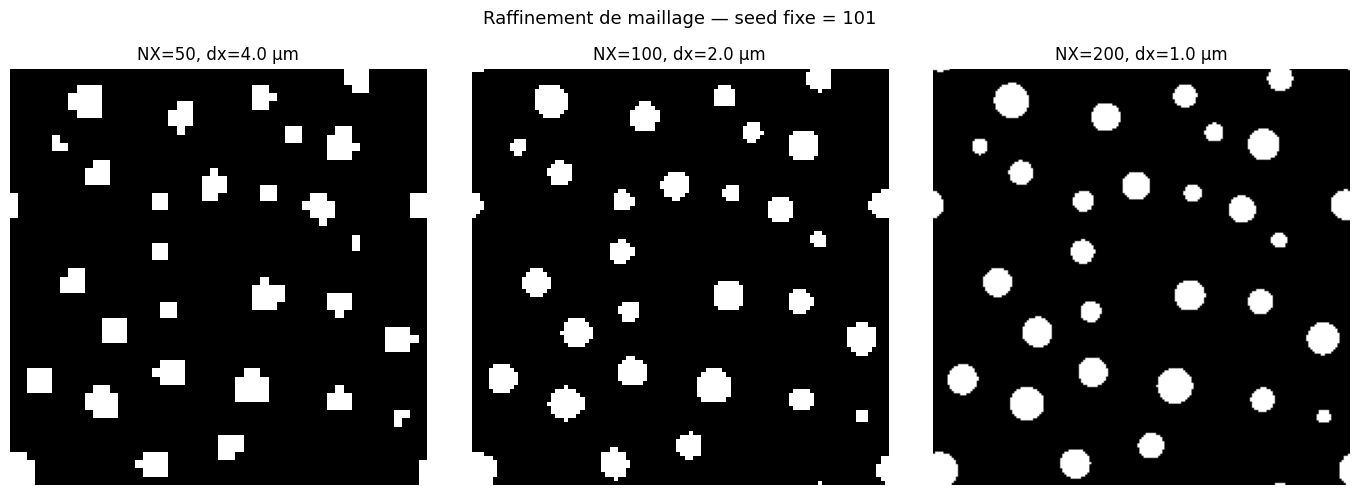

  NX= 50 : k_moy = 33.3472 ± 2.2730 µm²
  NX= 75 : k_moy = 31.0051 ± 2.0840 µm²
  NX=100 : k_moy = 29.8344 ± 1.8656 µm²
  NX=150 : k_moy = 29.2739 ± 2.0092 µm²
  NX=200 : k_moy = 29.0979 ± 1.9664 µm²
  Ordre apparent p    = 2.9242
  |p - pf|/pf         = 46.21 %
  k_num               = 29.0979 µm²
  u_num             = 0.1761 µm²


In [24]:

"""
Question A — Détermination de l'erreur numérique de la perméabilité calculée par LBM en fonction du maillage
"""
 
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import linregress

sys.path.append('..')
from devoir3_lbm_accelerated import Generate_sample, LBM

# Paramètres fixes
deltaP       = 0.1
poro         = 0.9
mean_fiber_d = 12.5
Ecart_type_D = 2.85
 
# Maillages — NX*dx = constante
NX_list = [50, 75, 100, 150, 200]
dx_list = [4e-6, 200/75*1e-6, 2e-6, 200/150*1e-6, 1e-6]
 
# Seeds de génération aléatoire pour la moyenne
seeds = [101, 102, 103, 104, 105, 106, 107]

# Moyenne sur plusieurs seeds pour chaque maillage
k_means = []   # perméabilité moyenne par maillage
k_stds  = []   # écart-type par maillage

# Simulation pour chaque maillage et chaque seed
for i in range(len(NX_list)):
    NX = NX_list[i] 
    dx = dx_list[i]
    k_list_seed = []

    for seed in seeds:
        filename = f'fiber_mat_NX{NX}_seed{seed}.tiff'
        d_eq = Generate_sample(seed, filename, mean_fiber_d, Ecart_type_D, poro, NX, dx, plot=False)
        k    = LBM(filename, NX, deltaP, dx, d_eq, plot=False)
        k_list_seed.append(k)
 
    k_mean = np.mean(k_list_seed) # perméabilité moyenne sur les seeds
    k_std  = np.std(k_list_seed, ddof=1) # écart-type sur les seeds (n-1 pour échantillon)
    k_means.append(k_mean) # moyenne pour ce maillage
    k_stds.append(k_std) # écart-type pour ce maillage
 
k_means  = np.array(k_means) # transformation en array pour les calculs
k_stds   = np.array(k_stds)
dx_array = np.array(dx_list)
 
# Erreur relative par rapport au maillage le plus fin (NX=200)
k_fin   = k_means[-1] 
err_rel    = np.abs(k_fin - k_means[:-1]) / k_fin
dx_coarse  = dx_array[:-1] # dx des maillages plus grossiers (NX=50, 75, 100, 150)
 
# Régression linéaire dans l'espace log-log pour estimer l'ordre de convergence apparent p
# log(err_rel) = p * log(dx) + cst 
log_dx  = np.log(dx_coarse)
log_err = np.log(err_rel)
 
slope, intercept, r_value, p_value, std_err = linregress(log_dx, log_err)
p_apparent = slope

# Calcul du rapport entre l'ordre de convergence apparent p et l'ordre théorique
pf     = 2
rapport = abs((p_apparent - pf) / pf)

# Calcul de u_num selon le rapport de l'ordre de convergence apparent p par rapport à l'ordre théorique 
r      = 2   # facteur de raffinement (rapport entre les dx successifs)

# Distinction des trois cas selon la valeur du rapport (cf. diapo 24 du cours sur la Vérification de solution)
if rapport < 0.01:
    k_extrap = k_means[-1] + (k_means[-1] - k_means[-2]) / (r**pf - 1)
    u_num    = 0.0
    k_num    = k_extrap
    print(f"  Branche <1% : extrapolation de Richardson")
    print(f"  k_num = k_extrap = {k_num:.4f} µm²  (pas d'incertitude)")
elif rapport <= 0.10:
    u_num = (1.25 / (r**pf - 1)) * abs(k_means[-2] - k_means[-1])
    k_num = k_means[-1]
    print(f"  Branche ≤10% : GCI (Fs=1.25, p=pf={pf})")
    print(f"  k_num = {k_num:.4f} µm²")
    print(f"  u_num = {u_num:.4f} µm²")
else:
    p_exp = min(max(0.5, p_apparent), pf)
    u_num = (3 / (r**p_exp - 1)) * abs(k_means[-2] - k_means[-1])
    k_num = k_means[-1]
    print(f"  Branche >10% : GCI (Fs=3, p_exp={p_exp:.2f})")
    print(f"  k_num = {k_num:.4f} µm²")
    print(f"  u_num = {u_num:.4f} µm²")

# Graphique 1 — Erreur relative en fonction de dx (log-log) avec régression linéaire 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
ax1 = axes[0]
dx_fit  = np.linspace(dx_coarse.min() * 0.8, dx_coarse.max() * 1.2, 100)
err_fit = np.exp(intercept) * dx_fit ** p_apparent
 
ax1.loglog(dx_coarse * 1e6, err_rel * 100, 'bo-', markersize=8, linewidth=2, label='Erreur relative')
ax1.loglog(dx_fit * 1e6, err_fit * 100, 'r--', linewidth=2, label=f'Régression : pente = {p_apparent:.2f}')
 
ax1.set_xlabel('dx (µm)', fontsize=12)
ax1.set_ylabel('Erreur relative (%)', fontsize=11)
ax1.set_title('Convergence en maillage (log-log)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)

# Graphique 2 — k moyen ± écart-type en fonction de dx
ax2 = axes[1]
ax2.errorbar(np.array(NX_list), k_means, yerr=k_stds, fmt='bo-', markersize=8, linewidth=2, capsize=5, label='k moyen ± écart-type (seeds)')
ax2.axhline(k_finest, color='r', linestyle='--', linewidth=1.5, label=f'k_finest = {k_finest:.2f} µm²')
ax2.fill_between(NX_list, k_finest - u_num, k_finest + u_num, color='red', alpha=0.15, label=f'±u_num = ±{u_num:.4f} µm²')
 
ax2.set_xlabel('NX', fontsize=12)
ax2.set_ylabel('k (µm²)', fontsize=12)
ax2.set_title('Perméabilité moyenne par niveau de maillage', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('convergence_maillage.png', dpi=150, bbox_inches='tight')
plt.show()
 

# Graphique 3 — Visualisation du raffinement (même seed, différents NX)
seed_visu = 101
NX_visu   = [50, 100, 200]
dx_visu   = [4e-6, 2e-6, 1e-6]
 
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 5))
fig2.suptitle(f'Raffinement de maillage — seed fixe = {seed_visu}\n', fontsize=13)
 
for j, (NX, dx) in enumerate(zip(NX_visu, dx_visu)):
    filename = f'fiber_mat_visu_NX{NX}.tiff'
    Generate_sample(seed_visu, filename, mean_fiber_d, Ecart_type_D, poro, NX, dx, plot=False)
    img = np.array(Image.open(filename))
    axes2[j].imshow(img, cmap='gray', origin='lower')
    axes2[j].set_title(f'NX={NX}, dx={dx*1e6:.1f} µm', fontsize=12)
    axes2[j].axis('off')
 
plt.tight_layout()
plt.savefig('raffinement_geometrie.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Affichage résumé des résultats
for i, NX in enumerate(NX_list):
    print(f"  NX={NX:3d} : k_moy = {k_means[i]:.4f} ± {k_stds[i]:.4f} µm²")
print(f"  Ordre apparent p    = {p_apparent:.4f}")
print(f"  |p - pf|/pf         = {rapport*100:.2f} %")
print(f"  k_num               = {k_num:.4f} µm²")
print(f"  u_num             = {u_num:.4f} µm²")

##### B)  Évaluer l’incertitude $u_{\text{input}}$ résultant de la propagation de l’incertitude des données d’entrée à l’aide d’un maillage suffisamment fin.

##### Pour ce faire, il vous faudra, par exemple, calculer la perméabilité pour diverses structures générées dont la porosité suit une distribution gaussienne (approche Monte Carlo classique).

##### Rapporter clairement ce que vous avez fait pour estimer cette incertitude (c.-à-d. donner la liste des paramètres, l’étendue de l’analyse effectuée et tous les graphiques que vous jugerez pertinents, en particulier la PDF ou la CDF des perméabilités générées par le code).

##### La distribution obtenue ne sera pas une distribution gaussienne (c’est-à-dire normale), mais log-normale (c’est-à-dire que ce sont les logarithmes des valeurs qui seront distribués de façon normale).

**Réponse :** 


d_equivalent     = 14.0598 µm
number_of_fibres = 27
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente normale.
  pas    500 | FlowRate = 4.426278e+02
  pas   1000 | FlowRate = 4.625273e+02
  pas   1500 | FlowRate = 4.638905e+02
  pas   2000 | FlowRate = 4.639935e+02
Convergence après 2458 pas de temps.

poro_eff         = 0.900500
Re               = 6.560216e-03
k_in_micron2     = 33.408135 µm²
d_equivalent     = 13.3902 µm
number_of_fibres = 32
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente normale.
  pas    500 | FlowRate = 3.491511e+02
  pas   1000 | FlowRate = 3.548079e+02
  pas   1500 | FlowRate = 3.549940e+02
Convergence après 1929 pas de temps.

poro_eff         = 0.893300
Re               = 4.421872e-03
k_in_micron2     = 25.560088 µm²
d_equivalent     = 12.8993 µm
number_of_fibres = 30
Démarrage LBM (Numba JIT multi-cœur)...
Compilation JIT au 1er pas — quelques secondes d'attente 

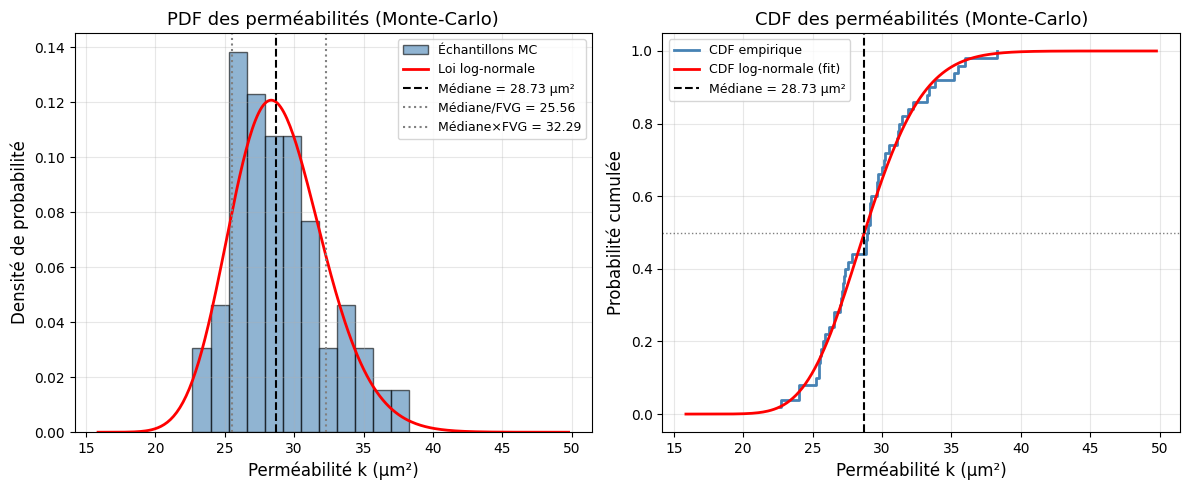

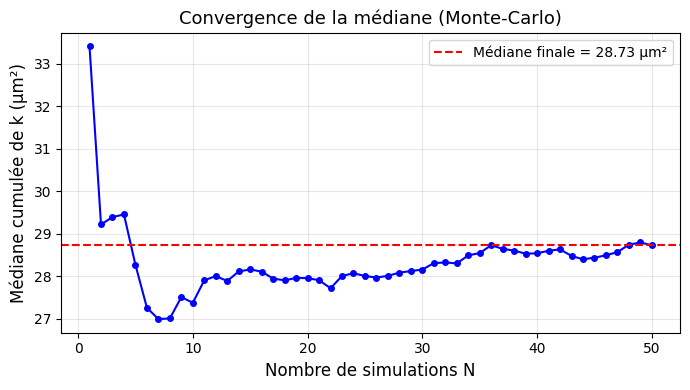

In [30]:
"""
Question B — Incertitude u_input par Monte-Carlo
Propagation de l'incertitude sur la porosité et le diamètre des fibres.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.append('..')

from devoir3_lbm_accelerated import Generate_sample, LBM

# Nombre de simulations Monte-Carlo
N_Monte_Carlo    = 50

# Paramètres physiques (Tableau 1)
D_moyen       = 12.5        # Diamètre moyen des fibres
Ecart_type_D        = 2.85        # Écart-type diamètre
Porosite_moyenne      = 0.900       # Porosité moyenne
Ecart_type_porosite   = 7.50e-3     # Écart-type porosité

# Paramètres LBM
NX           = 100         # Taille du domaine — Ne pas prendre le maillage le plus fin (NX=200) pour limiter le temps de calcul (l'erreur numérique est négligeable pour NX=100)
DX           = 2e-6        # Taille d'une cellule
DELTA_P      = 0.1         # Chute de pression

FILENAME     = 'fiber_mat_MC.tiff'

# Etude Monte-Carlo
rng = np.random.default_rng(seed=42)  # Même seed pour reproductibilité des tirages de porosité

permeabilities = []
porosities_eff = []
porosities_input = []

# Boucle Monte-Carlo pour 50 échantillons
for i in range(N_Monte_Carlo):
    poro_sample = rng.normal(Porosite_moyenne, Ecart_type_porosite) # Tirage de la porosité selon une loi normale 
    porosities_input.append(poro_sample)

   # Génération de l'échantillon 
    d_eq = Generate_sample(
        seed     = 0,          # La distribution de diamètres varie à chaque appel
        filename = FILENAME,
        mean_d   = D_moyen,
        std_d    = Ecart_type_D,
        poro     = poro_sample,
        nx       = NX,
        dx       = DX,
        plot     = False
    )

    # Simulation LBM pour calcul de la perméabilité
    k = LBM(
        filename     = FILENAME,
        NX           = NX,
        deltaP       = DELTA_P,
        dx           = DX,
        d_equivalent = d_eq,
        plot         = False
    )

    permeabilities.append(k)

permeabilities = np.array(permeabilities) # Transformation en array pour les calculs statistiques

# Analyse de la distribution log-normale

log_k    = np.log(permeabilities)
mu_log   = np.mean(log_k)
sigma_log = np.std(log_k, ddof=1)

# Paramètres log-normaux
mediane = np.exp(mu_log)         # Médiane de la distribution log-normale
FVG     = np.exp(sigma_log)      # Facteur de Variation Géométrique

print(f"Médiane des perméabilités simulées : {mediane:.2f} µm²")
print(f"Facteur de Variation Géométrique : {FVG:.2f}")

# Incertitude asymétrique
u_minus = mediane - mediane / FVG    # u_input⁻  (vers le bas)
u_plus  = mediane * FVG - mediane    # u_input⁺  (vers le haut)

print(f"Incertitude asymétrique : u_input⁻ = {u_minus:.2f} µm², u_input⁺ = {u_plus:.2f} µm²")

# Vérification fit log-normal avec scipy
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(permeabilities, floc=0)

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PDF en fonction de k avec fit log-normal et indication de la médiane et des bornes d'incertitude
ax1 = axes[0]
x_range = np.linspace(permeabilities.min() * 0.7, permeabilities.max() * 1.3, 300)
pdf_fitted = stats.lognorm.pdf(x_range, s=shape_ln, scale=scale_ln)

ax1.hist(permeabilities, bins=12, density=True, alpha=0.6, color='steelblue',
         edgecolor='black', label='Échantillons MC')
ax1.plot(x_range, pdf_fitted, 'r-', linewidth=2, label='Loi log-normale')
ax1.axvline(mediane, color='k', linestyle='--', linewidth=1.5, label=f'Médiane = {mediane:.2f} µm²')
ax1.axvline(mediane / FVG, color='gray', linestyle=':', linewidth=1.5, label=f'Médiane/FVG = {mediane/FVG:.2f}')
ax1.axvline(mediane * FVG, color='gray', linestyle=':', linewidth=1.5, label=f'Médiane×FVG = {mediane*FVG:.2f}')
ax1.set_xlabel('Perméabilité k (µm²)', fontsize=12)
ax1.set_ylabel('Densité de probabilité', fontsize=12)
ax1.set_title('PDF des perméabilités (Monte-Carlo)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# CDF empirique vs log-normal théorique et indication de la médiane et des bornes d'incertitude
ax2 = axes[1]
k_sorted = np.sort(permeabilities)
cdf_emp  = np.arange(1, N_Monte_Carlo + 1) / N_Monte_Carlo
cdf_fit  = stats.lognorm.cdf(x_range, s=shape_ln, scale=scale_ln)

ax2.step(k_sorted, cdf_emp, where='post', color='steelblue', linewidth=2, label='CDF empirique')
ax2.plot(x_range, cdf_fit, 'r-', linewidth=2, label='CDF log-normale (fit)')
ax2.axvline(mediane, color='k', linestyle='--', linewidth=1.5, label=f'Médiane = {mediane:.2f} µm²')
ax2.axhline(0.5, color='k', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_xlabel('Perméabilité k (µm²)', fontsize=12)
ax2.set_ylabel('Probabilité cumulée', fontsize=12)
ax2.set_title('CDF des perméabilités (Monte-Carlo)', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('MC_PDF_CDF.png', dpi=150, bbox_inches='tight')
plt.show()

# Etude de la convergence de la médiane en fonction du nombre de simulations N
fig2, ax3 = plt.subplots(figsize=(7, 4))
medianes_cumulees = [np.exp(np.mean(np.log(permeabilities[:n+1]))) for n in range(N_Monte_Carlo)]
ax3.plot(range(1, N_Monte_Carlo + 1), medianes_cumulees, 'b-o', markersize=4)
ax3.axhline(mediane, color='r', linestyle='--', linewidth=1.5, label=f'Médiane finale = {mediane:.2f} µm²')
ax3.set_xlabel('Nombre de simulations N', fontsize=12)
ax3.set_ylabel('Médiane cumulée de k (µm²)', fontsize=12)
ax3.set_title('Convergence de la médiane (Monte-Carlo)', fontsize=13)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('MC_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

##### C) Évaluer l’incertitude $u_D$ des données expérimentales en tenant compte de l’incertitude du perméamètre.

In [28]:
# Valeurs tirées du Tableau 1

u_repro    = 14.7    # Écart-type de la distribution supposée gaussienne des mesures de perméabilité lors d’un test de reproductibilité
u_permea   = 10.0    # Incertitude sur les mesures du perméamétre donnée par le manufacturier 

# Calcul de l'incertitude totale en combinant les contributions
u_D = (u_repro**2 + u_permea**2)**0.5

print(f"L'incertitude des données expérimentales (u_D) est estimée à : {u_D:.2f} µm²")

L'incertitude des données expérimentales (u_D) est estimée à : 17.78 µm²


Le résultat $u_D = 17,78 \ µm^2$ représente environ 22% de la médiane mesurée (80,6 µm²), ce qui est assez élevé.

**Réponse :** 


##### D) Obtenir l’erreur de la simulation $E$ en prenant la solution numérique $S$ et la valeur expérimentale $D$ comme étant les médianes des valeurs de perméabilité obtenues numériquement et expérimentalement.

In [ ]:
import numpy as np
 
S_median = 29.24    # médiane des perméabilités simulées (question B)
D_median = 80.6     # médiane des perméabilités mesurées (Tableau 1)

# Calcul de l'erreur de simulation E 
E = S_median - D_median

print(f"Erreur E = S_median - D_median = {E:.2f} µm²")

Erreur E = S_median - D_median = -51.36 µm²


**Réponse :** 
    


##### E) Déterminer l’erreur du modèle $\delta_{\text{model}}$ suivant le standard ASME V\&V20 et conclure sur l’adéquation du modèle numérique ainsi que sur les pistes d’amélioration éventuelles, si nécessaire.

**Réponse :** 
    


In [32]:
import numpy as np
 

u_num         = 0.1761   # incertitude numérique estimée à partir de l'étude de convergence (question A)
u_input_minus = 3.17     # u_input vers le bas (question B)
u_input_plus  = 3.56     # u_input vers le haut (question B)
S_median      = 29.24    # médiane des perméabilités simulées (question B)
u_repro       = 14.7     # (Tableau 1)
u_permea      = 10.0     # (Tableau 1)
D_median      = 80.6     # (Tableau 1)

u_D           = np.sqrt(u_repro**2 + u_permea**2) # incertitude des données expérimentales (question C)
E             = S_median - D_median # erreur de simulation (question D)

k             = 2 # Facteur de couverture k=2 pour intervalle de confiance à 95.4%
 
# u_val asymétrique : deux valeurs (bas et haut)
u_minus = np.sqrt(u_num**2 + u_input_minus**2 + u_D**2)
u_plus  = np.sqrt(u_num**2 + u_input_plus**2  + u_D**2)
 
# Intervalle de confiance à 95.4% sur δ_model
delta_model_low  = E - k * u_plus    # borne inférieure
delta_model_high = E + k * u_minus    # borne supérieure

print(f"  E - k·u_val⁺ ≤ δ_model ≤ E + k·u_val⁺")
print(f"  {E:.4f} - {p}×{u_plus:.4f} ≤ δ_model ≤ {E:.4f} + {p}×{u_minus:.4f}")
print(f"  δ_model appartient à l'intervalle  [{delta_model_low:.4f} , {delta_model_high:.4f}] µm²")



  E - k·u_val⁺ ≤ δ_model ≤ E + k·u_val⁺
  -51.3600 - 2×18.1327 ≤ δ_model ≤ -51.3600 + 2×18.0602
  δ_model appartient à l'intervalle  [-87.6254 , -15.2397] µm²


L'erreur du modèle appartient à un intervalle négatif donc le modèle numérique n'est pas adéquat. 